# 🛒 BigMart Sales Prediction - ML Model
**Goal:** Predict `Units_Sold` based on product and outlet features.

**Steps:**
1. Import Libraries
2. Load & Explore Dataset
3. Exploratory Data Analysis (EDA)
4. Data Preprocessing
5. Model Comparison (Linear Regression vs Random Forest vs Gradient Boosting)
6. Train Best Model (Gradient Boosting)
7. Evaluate & Visualize
8. Save Model

## 📦 Cell 1 — Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import joblib
import warnings
warnings.filterwarnings('ignore')

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


## 📂 Cell 2 — Load Dataset

In [2]:
df = pd.read_csv('big_market_sales_dataset.csv')

print('✅ Dataset loaded!')
print(f'Shape: {df.shape[0]} rows x {df.shape[1]} columns')
print(f'\nColumns: {list(df.columns)}')
print('\nFirst 5 rows:')
df.head()

✅ Dataset loaded!
Shape: 10000 rows x 13 columns

Columns: ['Item_ID', 'Item_Category', 'Item_MRP', 'Item_Visibility', 'Item_Fat_Content', 'Outlet_ID', 'Outlet_Type', 'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Establishment_Year', 'Festival_Flag', 'Discount_Percentage', 'Units_Sold']

First 5 rows:


,Item_ID,Item_Category,Item_MRP,Item_Visibility,Item_Fat_Content,Outlet_ID,Outlet_Type,Outlet_Size,Outlet_Location_Type,Outlet_Establishment_Year,Festival_Flag,Discount_Percentage,Units_Sold
0,ITM_00001,Personal Care,216.20,0.16,Low Fat,OUT_000,Supermarket Type3,Medium,Tier 3,2010,0,6,60
1,ITM_00002,Clothing,225.88,0.19,Non Edible,OUT_001,Supermarket Type3,Small,Tier 2,1997,0,42,115
2,ITM_00003,Household,301.07,0.19,Non Edible,OUT_002,Supermarket Type1,Medium,Tier 1,1996,0,36,160
3,ITM_00004,Clothing,270.16,0.06,Regular,OUT_003,Grocery Store,Medium,Tier 2,2006,0,8,33
4,ITM_00005,Clothing,91.89,0.21,Non Edible,OUT_004,Supermarket Type2,Medium,Tier 1,1993,1,13,149


## 🔍 Cell 3 — Dataset Info & Missing Values

In [3]:
print('=' * 50)
print('DATASET INFO')
print('=' * 50)
print(df.info())

print('\n' + '=' * 50)
print('MISSING VALUES')
print('=' * 50)
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else 'No missing values! ✅')

print('\n' + '=' * 50)
print('BASIC STATISTICS')
print('=' * 50)
df.describe()

DATASET INFO
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_ID                    10000 non-null  str    
 1   Item_Category              10000 non-null  str    
 2   Item_MRP                   10000 non-null  float64
 3   Item_Visibility            10000 non-null  float64
 4   Item_Fat_Content           10000 non-null  str    
 5   Outlet_ID                  10000 non-null  str    
 6   Outlet_Type                10000 non-null  str    
 7   Outlet_Size                10000 non-null  str    
 8   Outlet_Location_Type       10000 non-null  str    
 9   Outlet_Establishment_Year  10000 non-null  int64  
 10  Festival_Flag              10000 non-null  int64  
 11  Discount_Percentage        10000 non-null  int64  
 12  Units_Sold                 10000 non-null  int64  
dtypes: float64(2), int64(4), str(7)
memory usage:

,Item_MRP,Item_Visibility,Outlet_Establishment_Year,Festival_Flag,Discount_Percentage,Units_Sold
count,10000.000000,10000.000000,10000.00000,10000.0000,10000.000000,10000.000000
mean,260.473798,0.154852,2004.12430,0.2101,25.253400,112.565500
std,137.918707,0.083978,11.19171,0.4074,14.727786,39.780454
min,20.060000,0.010000,1985.00000,0.0000,0.000000,1.000000
25%,143.237500,0.080000,1994.00000,0.0000,12.000000,83.000000
50%,260.770000,0.150000,2004.00000,0.0000,26.000000,112.000000
75%,378.347500,0.230000,2014.00000,0.0000,38.000000,140.000000
max,499.950000,0.300000,2023.00000,1.0000,50.000000,254.000000


## 📊 Cell 4 — Target Variable Analysis

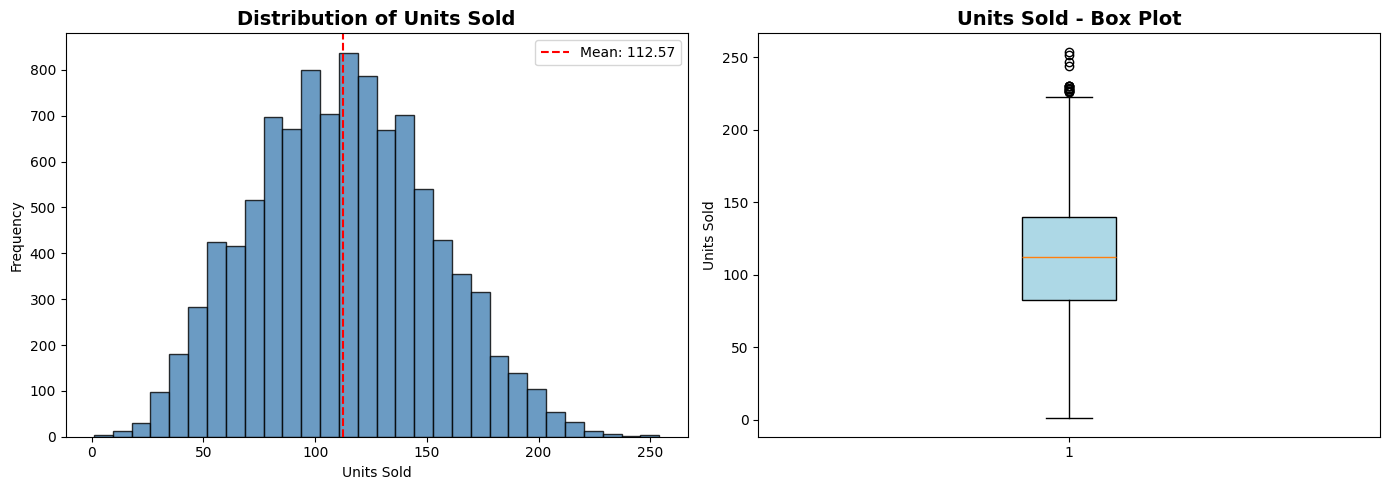

Min Units Sold  : 1
Max Units Sold  : 254
Mean Units Sold : 112.57
Median          : 112.00


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['Units_Sold'], bins=30, color='steelblue', edgecolor='black', alpha=0.8)
axes[0].set_title('Distribution of Units Sold', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Units Sold')
axes[0].set_ylabel('Frequency')
axes[0].axvline(df['Units_Sold'].mean(), color='red', linestyle='--', label=f'Mean: {df["Units_Sold"].mean():.2f}')
axes[0].legend()

axes[1].boxplot(df['Units_Sold'], patch_artist=True, boxprops=dict(facecolor='lightblue'))
axes[1].set_title('Units Sold - Box Plot', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Units Sold')

plt.tight_layout()
plt.savefig('screenshots/target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Min Units Sold  : {df["Units_Sold"].min()}')
print(f'Max Units Sold  : {df["Units_Sold"].max()}')
print(f'Mean Units Sold : {df["Units_Sold"].mean():.2f}')
print(f'Median          : {df["Units_Sold"].median():.2f}')

## 📊 Cell 5 — EDA: Category & Outlet Analysis

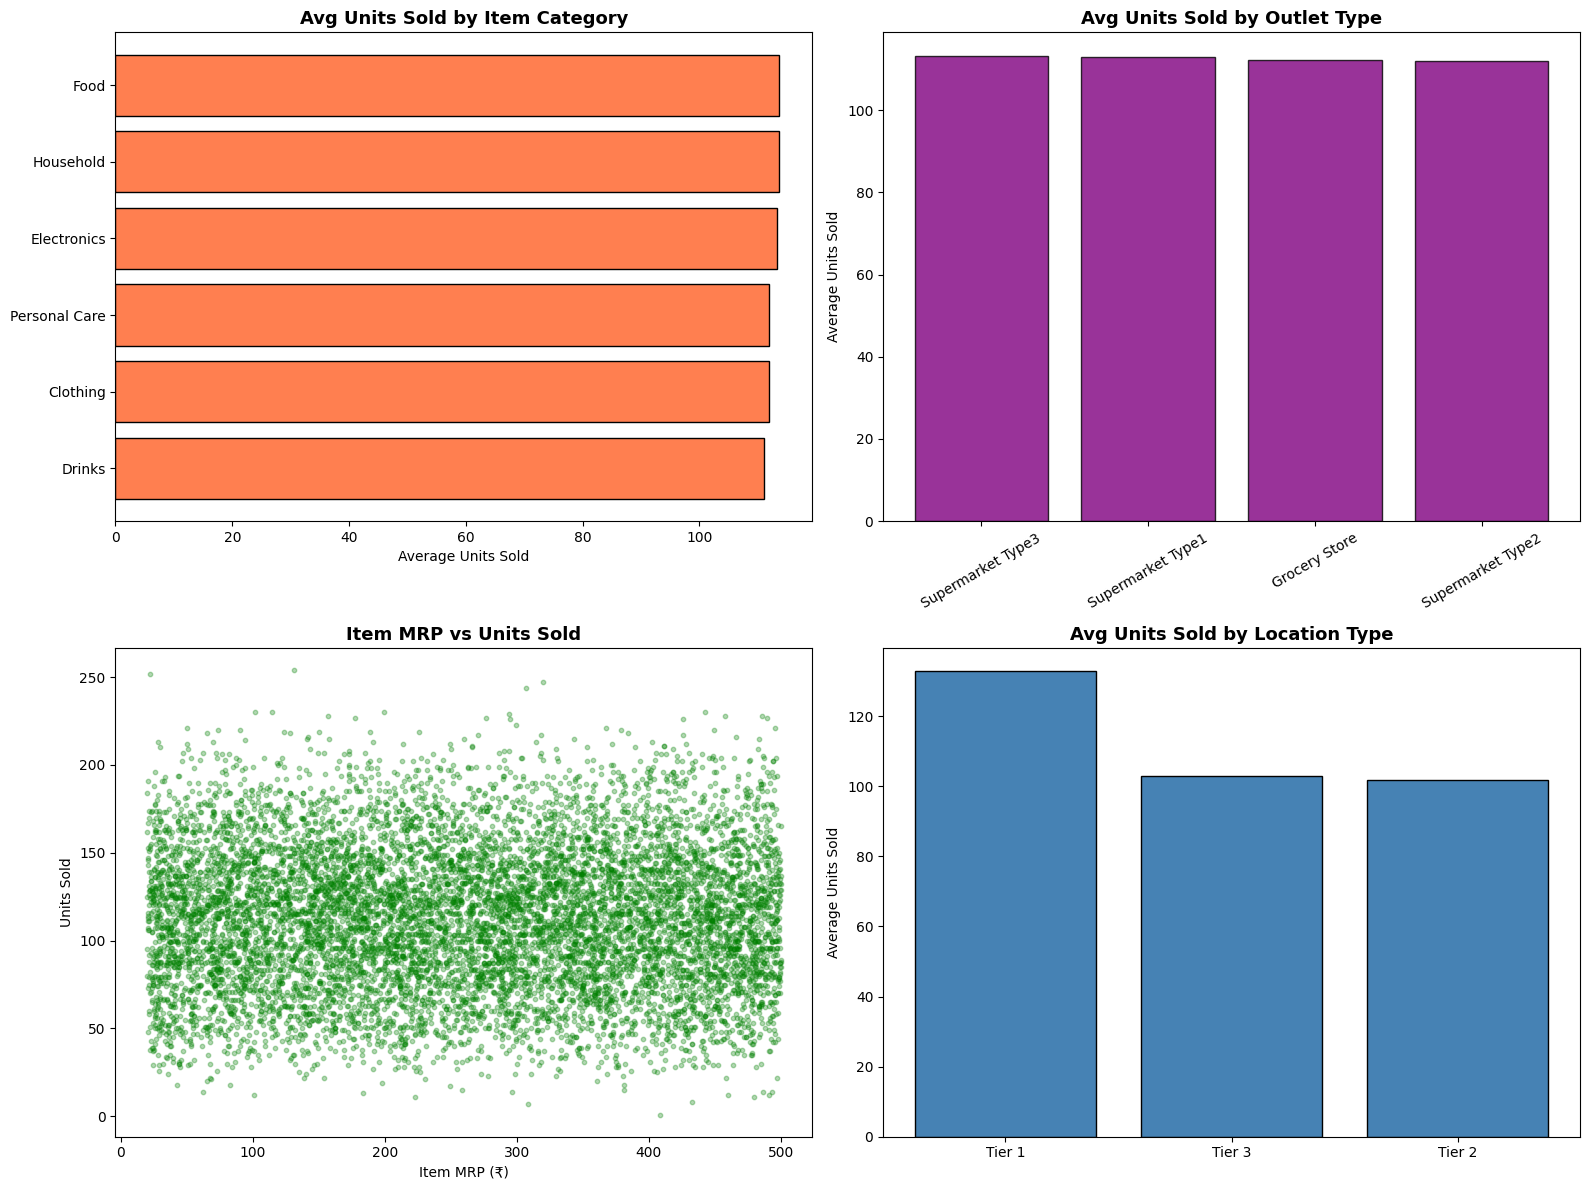

✅ EDA plots saved!


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

category_sales = df.groupby('Item_Category')['Units_Sold'].mean().sort_values(ascending=True)
axes[0,0].barh(category_sales.index, category_sales.values, color='coral', edgecolor='black')
axes[0,0].set_title('Avg Units Sold by Item Category', fontsize=13, fontweight='bold')
axes[0,0].set_xlabel('Average Units Sold')

outlet_sales = df.groupby('Outlet_Type')['Units_Sold'].mean().sort_values(ascending=False)
axes[0,1].bar(outlet_sales.index, outlet_sales.values, color='purple', edgecolor='black', alpha=0.8)
axes[0,1].set_title('Avg Units Sold by Outlet Type', fontsize=13, fontweight='bold')
axes[0,1].set_ylabel('Average Units Sold')
axes[0,1].tick_params(axis='x', rotation=30)

axes[1,0].scatter(df['Item_MRP'], df['Units_Sold'], alpha=0.3, color='green', s=10)
axes[1,0].set_title('Item MRP vs Units Sold', fontsize=13, fontweight='bold')
axes[1,0].set_xlabel('Item MRP (₹)')
axes[1,0].set_ylabel('Units Sold')

location_sales = df.groupby('Outlet_Location_Type')['Units_Sold'].mean().sort_values(ascending=False)
axes[1,1].bar(location_sales.index, location_sales.values, color='steelblue', edgecolor='black')
axes[1,1].set_title('Avg Units Sold by Location Type', fontsize=13, fontweight='bold')
axes[1,1].set_ylabel('Average Units Sold')

plt.tight_layout()
plt.savefig('screenshots/eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ EDA plots saved!')

## 📊 Cell 6 — Correlation Heatmap

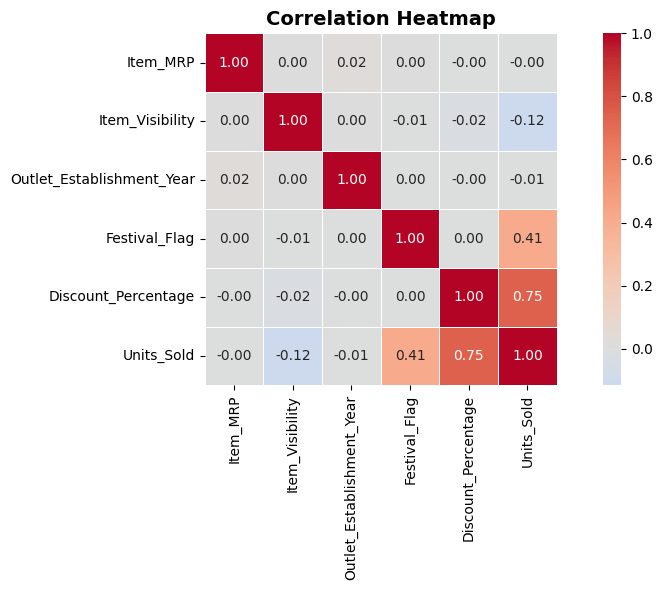

✅ Heatmap saved!


In [6]:
numeric_df = df.select_dtypes(include=[np.number])

plt.figure(figsize=(10, 6))
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5)
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('screenshots/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Heatmap saved!')

## ⚙️ Cell 7 — Data Preprocessing

In [7]:
drop_cols = [col for col in ['Item_ID', 'Outlet_ID'] if col in df.columns]
if drop_cols:
    df.drop(drop_cols, axis=1, inplace=True)
    print(f'Dropped columns: {drop_cols}')

X = df.drop('Units_Sold', axis=1)
y = df['Units_Sold']

cat_cols = X.select_dtypes(include='object').columns.tolist()
num_cols = X.select_dtypes(exclude='object').columns.tolist()

print(f'Features shape  : {X.shape}')
print(f'Target shape    : {y.shape}')
print(f'Categorical cols: {cat_cols}')
print(f'Numerical cols  : {num_cols}')

Dropped columns: ['Item_ID', 'Outlet_ID']
Features shape  : (10000, 10)
Target shape    : (10000,)
Categorical cols: ['Item_Category', 'Item_Fat_Content', 'Outlet_Type', 'Outlet_Size', 'Outlet_Location_Type']
Numerical cols  : ['Item_MRP', 'Item_Visibility', 'Outlet_Establishment_Year', 'Festival_Flag', 'Discount_Percentage']


## 🔀 Cell 8 — Train Test Split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Training set : {X_train.shape[0]} samples (80%)')
print(f'Testing set  : {X_test.shape[0]} samples (20%)')

Training set : 8000 samples (80%)
Testing set  : 2000 samples (20%)


## 🔧 Cell 9 — Build Preprocessor

In [9]:
preprocessor = ColumnTransformer(transformers=[
    ('categorical', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols),
    ('numerical', StandardScaler(), num_cols)
])
print('✅ Preprocessor built!')

✅ Preprocessor built!


## 🏆 Cell 10 — Model Comparison

In [10]:
print('Comparing 3 models... ⏳ (takes 2-3 minutes)\n')

models = {
    'Linear Regression' : LinearRegression(),
    'Random Forest'     : RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting' : GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, max_depth=5, random_state=42)
}

results = {}
for name, model in models.items():
    print(f'Training {name}...')
    pipe = Pipeline([('preprocessing', preprocessor), ('model', model)])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    results[name] = {
        'R² Score' : round(r2_score(y_test, y_pred), 4),
        'RMSE'     : round(np.sqrt(mean_squared_error(y_test, y_pred)), 4)
    }
    print(f'   ✅ R²={results[name]["R² Score"]}  RMSE={results[name]["RMSE"]}')

comparison_df = pd.DataFrame(results).T
print('\n' + '=' * 55)
print('         MODEL COMPARISON RESULTS')
print('=' * 55)
print(comparison_df.to_string())
print('=' * 55)
best_model_name = comparison_df['R² Score'].idxmax()
print(f'\n🏆 Best Model: {best_model_name}')

Comparing 3 models... ⏳ (takes 2-3 minutes)

Training Linear Regression...
   ✅ R²=0.8597  RMSE=14.9904
Training Random Forest...
   ✅ R²=0.8409  RMSE=15.9605
Training Gradient Boosting...
   ✅ R²=0.8499  RMSE=15.5022

         MODEL COMPARISON RESULTS
                   R² Score     RMSE
Linear Regression    0.8597  14.9904
Random Forest        0.8409  15.9605
Gradient Boosting    0.8499  15.5022

🏆 Best Model: Linear Regression


## 📊 Cell 11 — Model Comparison Chart

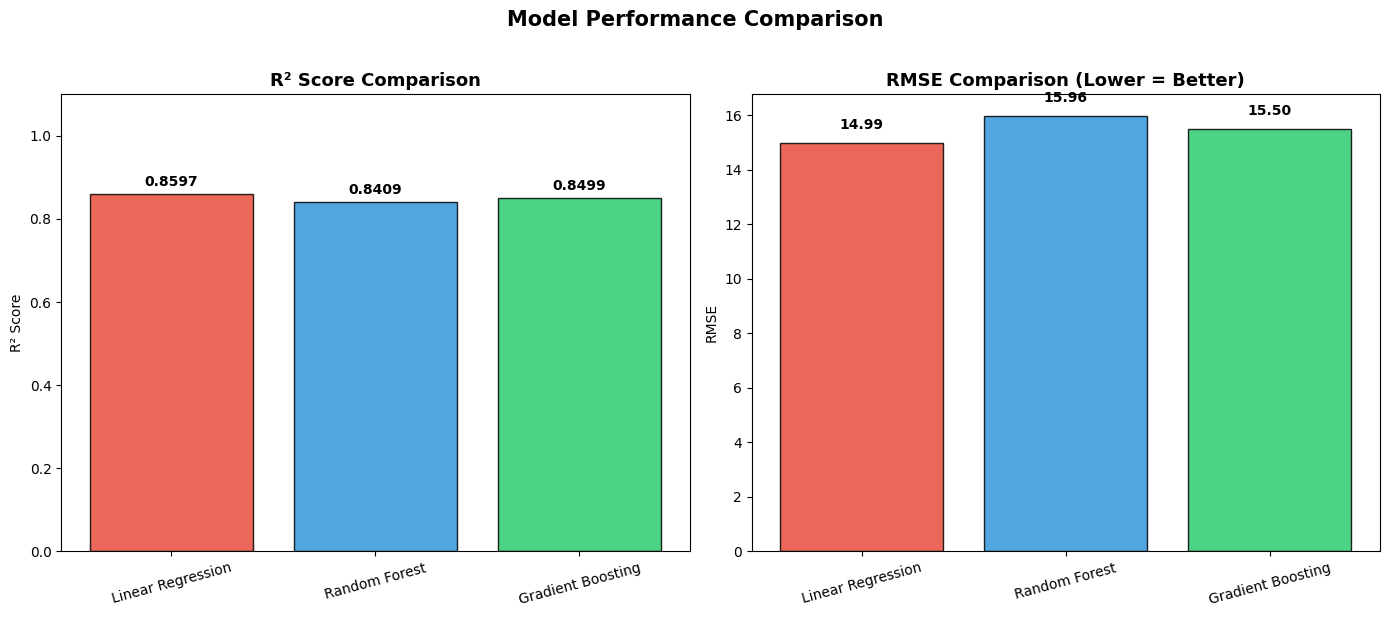

✅ Model comparison chart saved!


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
model_names = list(results.keys())
r2_scores   = [results[m]['R² Score'] for m in model_names]
rmse_scores = [results[m]['RMSE'] for m in model_names]
colors      = ['#e74c3c', '#3498db', '#2ecc71']

bars1 = axes[0].bar(model_names, r2_scores, color=colors, edgecolor='black', alpha=0.85)
axes[0].set_title('R² Score Comparison', fontsize=13, fontweight='bold')
axes[0].set_ylabel('R² Score')
axes[0].set_ylim(0, 1.1)
axes[0].tick_params(axis='x', rotation=15)
for bar, score in zip(bars1, r2_scores):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'{score:.4f}', ha='center', fontweight='bold')

bars2 = axes[1].bar(model_names, rmse_scores, color=colors, edgecolor='black', alpha=0.85)
axes[1].set_title('RMSE Comparison (Lower = Better)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('RMSE')
axes[1].tick_params(axis='x', rotation=15)
for bar, score in zip(bars2, rmse_scores):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{score:.2f}', ha='center', fontweight='bold')

plt.suptitle('Model Performance Comparison', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('screenshots/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Model comparison chart saved!')

## 🚀 Cell 12 — Train Final Gradient Boosting Model

In [12]:
print('Training final Gradient Boosting model... ⏳')

final_model = Pipeline([
    ('preprocessing', preprocessor),
    ('model', GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        min_samples_split=5,
        min_samples_leaf=3,
        subsample=0.8,
        random_state=42
    ))
])

final_model.fit(X_train, y_train)
print('✅ Final model trained!')

Training final Gradient Boosting model... ⏳
✅ Final model trained!


## 📈 Cell 13 — Evaluate Final Model

In [13]:
y_pred_train = final_model.predict(X_train)
y_pred_test  = final_model.predict(X_test)

r2_train   = r2_score(y_train, y_pred_train)
r2_test    = r2_score(y_test, y_pred_test)
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
rmse_test  = np.sqrt(mean_squared_error(y_test, y_pred_test))

print('=' * 50)
print('   FINAL GRADIENT BOOSTING PERFORMANCE')
print('=' * 50)
print(f'  R² Score  (Train) : {r2_train:.4f}')
print(f'  R² Score  (Test)  : {r2_test:.4f}')
print(f'  RMSE      (Train) : {rmse_train:.4f}')
print(f'  RMSE      (Test)  : {rmse_test:.4f}')
print('=' * 50)

if r2_test >= 0.85:
    print('🎉 Excellent model performance!')
elif r2_test >= 0.75:
    print('👍 Good model performance!')
else:
    print('⚠️ Model needs more tuning.')

   FINAL GRADIENT BOOSTING PERFORMANCE
  R² Score  (Train) : 0.8997
  R² Score  (Test)  : 0.8525
  RMSE      (Train) : 12.5766
  RMSE      (Test)  : 15.3716
🎉 Excellent model performance!


## 📊 Cell 14 — Performance Visualizations

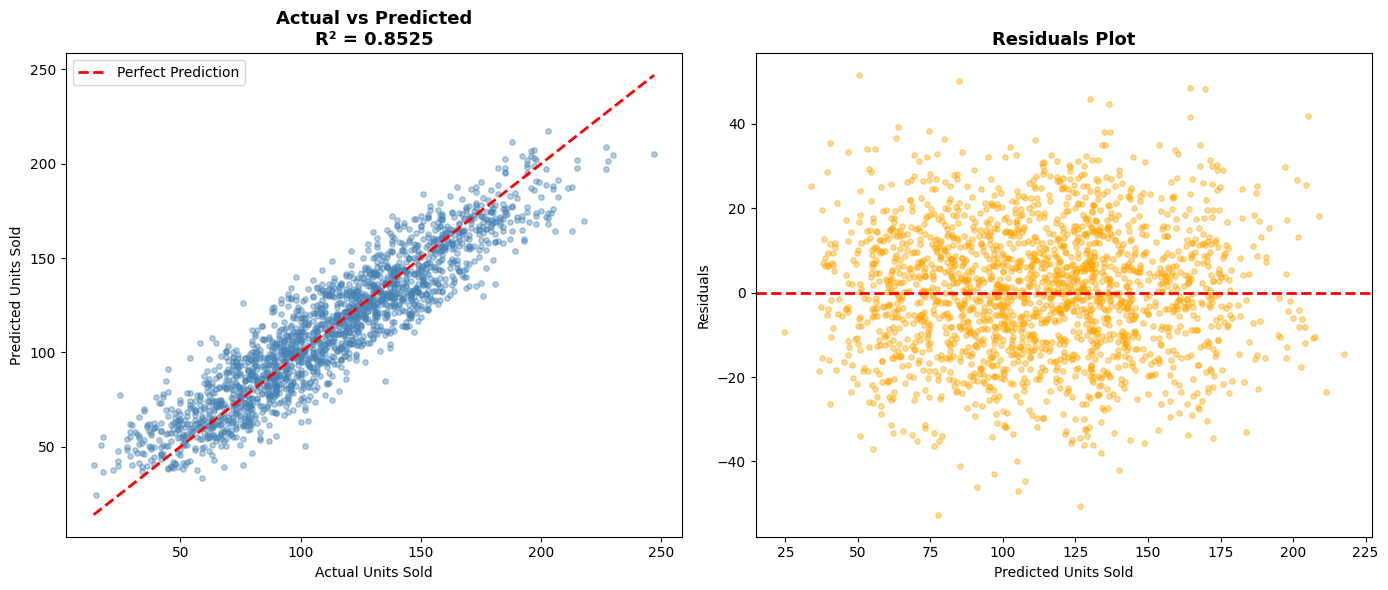

✅ Performance plots saved!


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(y_test, y_pred_test, alpha=0.4, color='steelblue', s=15)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
             'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Units Sold')
axes[0].set_ylabel('Predicted Units Sold')
axes[0].set_title(f'Actual vs Predicted\nR² = {r2_test:.4f}', fontsize=13, fontweight='bold')
axes[0].legend()

residuals = y_test - y_pred_test
axes[1].scatter(y_pred_test, residuals, alpha=0.4, color='orange', s=15)
axes[1].axhline(y=0, color='red', linestyle='--', lw=2)
axes[1].set_xlabel('Predicted Units Sold')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Residuals Plot', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('screenshots/model_performance.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Performance plots saved!')

## 🌟 Cell 15 — Feature Importance

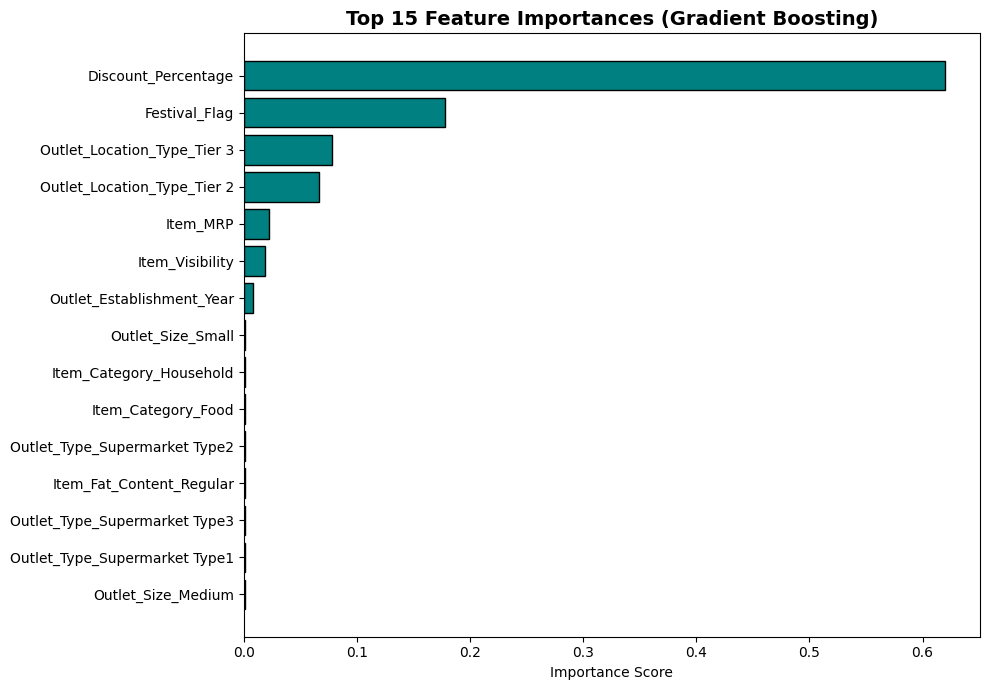

Top 10 Most Important Features:
                    Feature  Importance
        Discount_Percentage    0.619752
              Festival_Flag    0.177442
Outlet_Location_Type_Tier 3    0.078045
Outlet_Location_Type_Tier 2    0.066376
                   Item_MRP    0.021904
            Item_Visibility    0.018817
  Outlet_Establishment_Year    0.008268
          Outlet_Size_Small    0.000947
    Item_Category_Household    0.000925
         Item_Category_Food    0.000898

✅ Feature importance saved!


In [15]:
ohe = final_model.named_steps['preprocessing'].transformers_[0][1]
cat_feature_names = ohe.get_feature_names_out(cat_cols).tolist()
all_feature_names = cat_feature_names + num_cols

importances = final_model.named_steps['model'].feature_importances_
feature_df = pd.DataFrame({
    'Feature'    : all_feature_names,
    'Importance' : importances
}).sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(10, 7))
plt.barh(feature_df['Feature'][::-1], feature_df['Importance'][::-1],
         color='teal', edgecolor='black')
plt.title('Top 15 Feature Importances (Gradient Boosting)', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('screenshots/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 10 Most Important Features:')
print(feature_df[['Feature', 'Importance']].head(10).to_string(index=False))
print('\n✅ Feature importance saved!')

## 💾 Cell 16 — Save Final Model

In [16]:
joblib.dump(final_model, 'rf_model.pkl')
print('✅ Model saved as rf_model.pkl')

# Verify
loaded_model = joblib.load('rf_model.pkl')
test_pred = loaded_model.predict(X_test[:5])
print(f'\n✅ Verified! Sample predictions : {test_pred.round(2)}')
print(f'   Actual values               : {y_test[:5].values}')

print('\n' + '=' * 50)
print('           FINAL SUMMARY')
print('=' * 50)
print(f'  Algorithm    : Gradient Boosting Regressor')
print(f'  Estimators   : 300')
print(f'  Learning Rate: 0.05')
print(f'  R² Score     : {r2_test:.4f}')
print(f'  RMSE         : {rmse_test:.4f}')
print(f'  Features     : {len(all_feature_names)}')
print('=' * 50)

✅ Model saved as rf_model.pkl

✅ Verified! Sample predictions : [ 97.43  46.78 100.15  75.7  101.05]
   Actual values               : [72 34 89 77 83]

           FINAL SUMMARY
  Algorithm    : Gradient Boosting Regressor
  Estimators   : 300
  Learning Rate: 0.05
  R² Score     : 0.8525
  RMSE         : 15.3716
  Features     : 19
